# **Deep Learning for Classification**

**Student Performance Prediction Using Artificial Neural Networks**

**Step 1: Import Libraries**

 These libraries help us prepare the data, build the neural network, train it, improve it, and evaluate performance.

In [ ]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

**Step 2: Upload and Load Dataset**

This allows you to upload student_performance_dataset.csv into Google Colab.

In [ ]:
# Import files module from Google Colab
from google.colab import files

# Open file upload option
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

This confirms that the dataset is loaded correctly.

In [ ]:
# Import pandas for reading and handling dataset
import pandas as pd

# Read the uploaded CSV file
data = pd.read_csv("student_performance_dataset.csv")

# Display the first five rows
print(data.head())

   study_hours  attendance  assignment_score  previous_score  participation  \
0     3.745401   51.107976         26.170568       67.270299       5.719959   
1     9.507143   72.514057         24.697880       79.668140       8.054323   
2     7.319939   92.376750         90.625458       25.046790       7.601609   
3     5.986585   83.933493         24.954620       62.487410       1.538999   
4     1.560186   88.393669         27.194973       57.174598       1.492495   

   passed  
0       1  
1       1  
2       1  
3       1  
4       1  


**Step 3: Inspect the Dataset**

Before modeling, we check whether the dataset is complete and whether pass/fail classes are balanced.



In [ ]:
# Show dataset size
print("Dataset shape:", data.shape)

# Show column names
print("Columns:", data.columns.tolist())

# Check missing values
print(data.isnull().sum())

# Show target distribution
print(data["passed"].value_counts())

Dataset shape: (1000, 6)
Columns: ['study_hours', 'attendance', 'assignment_score', 'previous_score', 'participation', 'passed']
study_hours         0
attendance          0
assignment_score    0
previous_score      0
participation       0
passed              0
dtype: int64
passed
1    780
0    220
Name: count, dtype: int64


**Step 4: Separate Features and Target**  

X contains the student features, while y contains whether the student passed or failed.

In [ ]:
# Store all input columns except the target
X = data.drop("passed", axis=1)

# Store the target column
y = data["passed"]

In [ ]:
# Count how many students passed and failed
print(data["passed"].value_counts())

passed
1    780
0    220
Name: count, dtype: int64


**Step 5: Split Dataset**

We use 80% of the data for training and 20% for testing. stratify=y keeps the same pass/fail ratio in both sets.

In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Step 6: Scale the Features**

Scaling makes all features comparable. This helps neural networks train faster and more reliably.

In [ ]:
# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

**Step 7: Build the First Artificial Neural Network**

This is the baseline model from the previous project. We will compare it with the improved model.

In [ ]:
from tensorflow.keras import layers
# Create a basic neural network model
basic_model = keras.Sequential([

    # Input layer based on number of features
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),

    # First hidden layer
    keras.layers.Dense(16, activation="relu"),

    # Second hidden layer
    keras.layers.Dense(8, activation="relu"),

    # Output layer for binary classification
    keras.layers.Dense(1, activation="sigmoid")
])

**Step 8: View Neural Network Architecture**

In [ ]:
# Show model architecture
basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

**Step 9: Compile the Neural Network**
*  adam updates the model weights.
*  binary_crossentropy is appropriate for pass/fail prediction.
*  accuracy measures correct predictions.

In [ ]:
# Compile the basic model
basic_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

**Step 10: Train the Neural Network**

We train for 50 epochs to observe whether the model continues improving or begins overfitting.

In [ ]:
# Train the basic model
basic_history = basic_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6266 - loss: 0.6290 - val_accuracy: 0.6875 - val_loss: 0.6566
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7266 - loss: 0.5634 - val_accuracy: 0.7437 - val_loss: 0.6029
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7719 - loss: 0.5164 - val_accuracy: 0.7625 - val_loss: 0.5616
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7797 - loss: 0.4792 - val_accuracy: 0.7688 - val_loss: 0.5275
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7828 - loss: 0.4494 - val_accuracy: 0.7688 - val_loss: 0.4994
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7828 - loss: 0.4246 - val_accuracy: 0.7688 - val_loss: 0.4798
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7812 - loss: 0.4056 - val_accuracy: 0.7688 - val_loss: 0.4614
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7812 - loss: 0.3884 - val_accuracy: 0.7688 - val_l

**Step 11: Visualize Training Performance**  

If training accuracy increases but validation accuracy stops improving, the model may be overfitting.

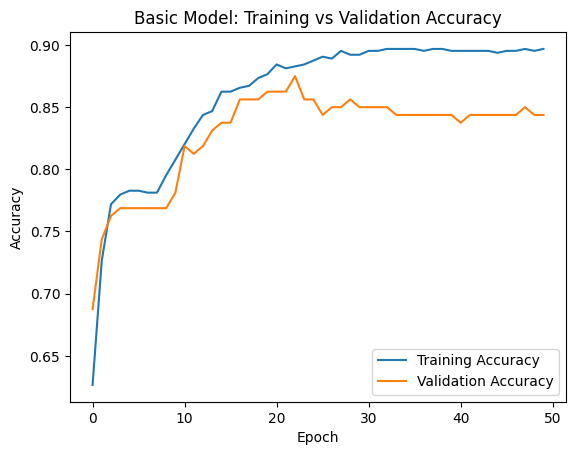

In [ ]:
# Plot training accuracy
plt.plot(basic_history.history["accuracy"], label="Training Accuracy")

# Plot validation accuracy
plt.plot(basic_history.history["val_accuracy"], label="Validation Accuracy")

# Add title
plt.title("Basic Model: Training vs Validation Accuracy")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Accuracy")

# Add legend
plt.legend()

# Show plot
plt.show()

**Step 12: Visualize Loss Curves**

Loss shows error. If validation loss increases while training loss decreases, the model is overfitting.

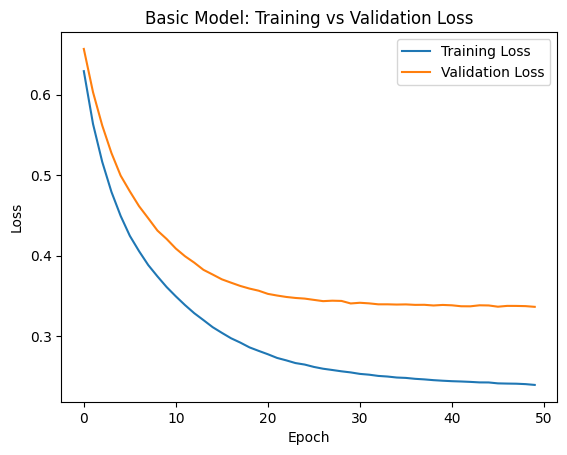

In [ ]:
# Plot training loss
plt.plot(basic_history.history["loss"], label="Training Loss")

# Plot validation loss
plt.plot(basic_history.history["val_loss"], label="Validation Loss")

# Add title
plt.title("Basic Model: Training vs Validation Loss")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Loss")

# Add legend
plt.legend()

# Show plot
plt.show()

**Step 13: Understanding Overfitting**

# **Build an Improved Neural Network**

**Step 14: Build an Improved Model with Dropout**

Dropout helps reduce overfitting by preventing the network from depending too much on specific neurons.

In [ ]:
# Create improved neural network model
improved_model = keras.Sequential([

    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # First hidden layer with more neurons
    layers.Dense(32, activation="relu"),

    # Dropout layer randomly turns off 30% of neurons during training
    layers.Dropout(0.3),

    # Second hidden layer
    layers.Dense(16, activation="relu"),

    # Dropout layer randomly turns off 20% of neurons during training
    layers.Dropout(0.2),

    # Output layer
    layers.Dense(1, activation="sigmoid")
])

**Step 15: Understanding Dropout**

In [ ]:
print("Dropout Layer 1: 30% neurons disabled during training")

print("Dropout Layer 2: 20% neurons disabled during training")

print("Dropout helps reduce overfitting")

Dropout Layer 1: 30% neurons disabled during training
Dropout Layer 2: 20% neurons disabled during training
Dropout helps reduce overfitting


**Step 16: Compile Improved Model with Controlled Learning Rate**  

The learning rate controls how large the model’s weight updates are. If it is too high, training may become unstable. If it is too low, training may be slow.

In [ ]:
# Create Adam optimizer with specific learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.001)

# Compile improved model
improved_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

**Step 17: Early Stopping**
*  EarlyStopping prevents unnecessary training.
*  ReduceLROnPlateau lowers learning rate when progress slows.
*  ModelCheckpoint saves the best version of the model.


In [ ]:
# Stop training when validation loss stops improving
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


**Step 18: Learning Rate Reduction**

Another powerful optimization technique is Learning Rate Reduction.

In [ ]:

# Reduce learning rate when validation loss stops improving
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)



**Step 19: Model Checkpointing**

In [ ]:
# Save the best model during training
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="best_student_model.keras",
    monitor="val_loss",
    save_best_only=True
)

**Step 20: Train the Improved Model**

We set a high number of epochs, but early stopping will stop training automatically when the model stops improving.

In [ ]:
# Train improved model with callbacks
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8703 - loss: 0.3138 - val_accuracy: 0.8875 - val_loss: 0.3165 - learning_rate: 6.2500e-05
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8813 - loss: 0.2860 - val_accuracy: 0.8875 - val_loss: 0.3164 - learning_rate: 6.2500e-05
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8703 - loss: 0.3012 - val_accuracy: 0.8875 - val_loss: 0.3164 - learning_rate: 6.2500e-05
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8656 - loss: 0.2842 - val_accuracy: 0.8875 - val_loss: 0.3164 - learning_rate: 6.2500e-05
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8594 - loss: 0.3012 - val_accuracy: 0.8813 - val_loss: 0.3164 - learning_rate: 6.2500e-05
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8672 - loss: 0.2949 - val_accuracy: 0.8875 - val_loss: 0.3164 - learning_rate: 6.2500e-05
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8734 

**Step 21: Evaluate the Improved Model**

This shows whether dropout, learning rate control, and early stopping improved the model.

This tells us how the original model performs on unseen data.

In [ ]:
# Evaluate basic model on test data
basic_loss, basic_accuracy = basic_model.evaluate(X_test_scaled, y_test)

# Print basic model results
print("Basic Model Loss:", basic_loss)
print("Basic Model Accuracy:", basic_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8650 - loss: 0.3266 
Basic Model Loss: 0.326568603515625
Basic Model Accuracy: 0.8650000095367432


In [ ]:
# Evaluate improved model on test data
improved_loss, improved_accuracy = improved_model.evaluate(X_test_scaled, y_test)

# Print improved model results
print("Improved Model Loss:", improved_loss)
print("Improved Model Accuracy:", improved_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8500 - loss: 0.3163 
Improved Model Loss: 0.31630218029022217
Improved Model Accuracy: 0.8500000238418579


**Step 22: Compare Baseline and Improved Models**

This gives students a clear visual comparison between the basic and improved models.
This makes the improvement visible and easy for students to understand.

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Basic Model", "Improved Model"],
    "Test Loss": [basic_loss, improved_loss],
    "Test Accuracy": [basic_accuracy, improved_accuracy]
})

# Show comparison
print(comparison)

            Model  Test Loss  Test Accuracy
0     Basic Model   0.326569          0.865
1  Improved Model   0.316302          0.850


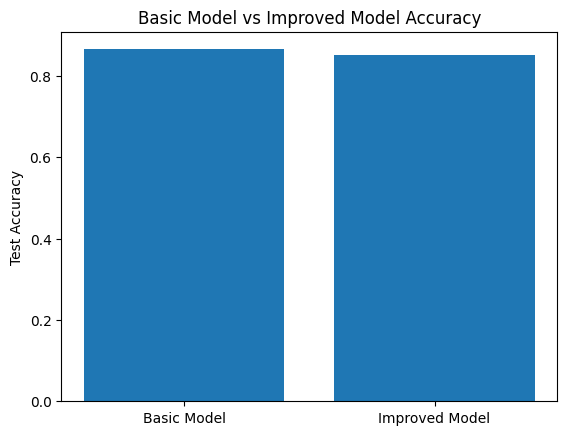

In [ ]:
# Plot model accuracy comparison
plt.bar(comparison["Model"], comparison["Test Accuracy"])

# Add title
plt.title("Basic Model vs Improved Model Accuracy")

# Add y-axis label
plt.ylabel("Test Accuracy")

# Show chart
plt.show()

**Step 23: Visualize Training Loss**  

This shows how well the improved model learned during training.

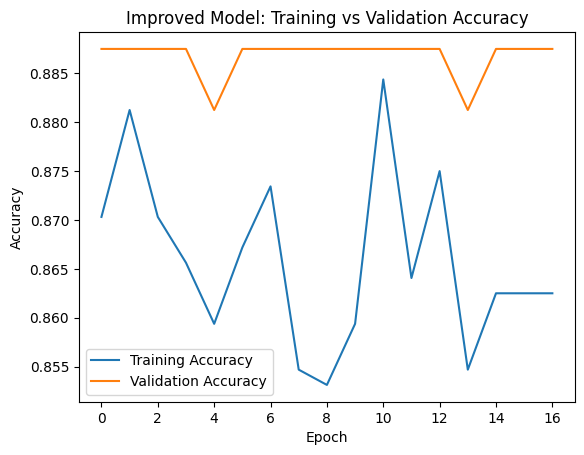

In [ ]:
# Plot improved model training accuracy
plt.plot(improved_history.history["accuracy"], label="Training Accuracy")

# Plot improved model validation accuracy
plt.plot(improved_history.history["val_accuracy"], label="Validation Accuracy")

# Add title
plt.title("Improved Model: Training vs Validation Accuracy")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Accuracy")

# Add legend
plt.legend()

# Show plot
plt.show()

**Step 24: Visualize Training Loss**

This helps students see whether regularization reduced overfitting.

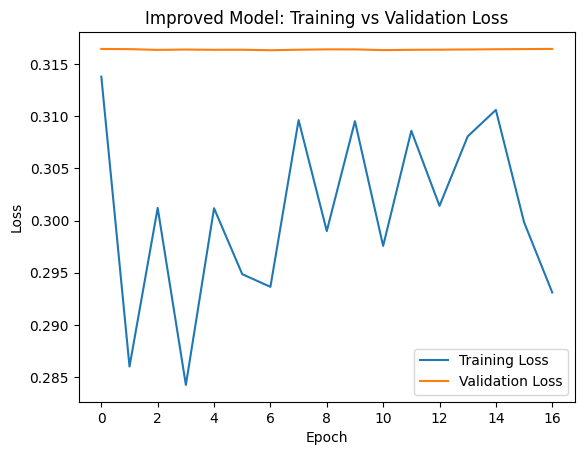

In [ ]:
# Plot improved model training loss
plt.plot(improved_history.history["loss"], label="Training Loss")

# Plot improved model validation loss
plt.plot(improved_history.history["val_loss"], label="Validation Loss")

# Add title
plt.title("Improved Model: Training vs Validation Loss")

# Add x-axis label
plt.xlabel("Epoch")

# Add y-axis label
plt.ylabel("Loss")

# Add legend
plt.legend()

# Show plot
plt.show()

**Step 25: Make Predictions with Improved Model**

The model outputs probabilities. We convert them into pass/fail labels using 0.5 as the threshold.

In [ ]:
# Predict probabilities using improved model
y_pred_prob = improved_model.predict(X_test_scaled)

# Convert probabilities into class labels
y_pred = (y_pred_prob > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


**Step 26: Convert Probabilities into Class Labels**

In [ ]:
predicted_classes = (

    y_pred_prob > 0.5

).astype(int)

print(predicted_classes[:10])

[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]]


**Step 27: Confusion Matrix**

The confusion matrix shows correct and incorrect predictions for both classes.

In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 28  16]
 [ 14 142]]


**Step 28: Classification Report**

This report shows precision, recall, and F1-score.

In [ ]:
from sklearn.metrics import classification_report

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

**Step 29: Save the Improved Model**
Saving the model allows reuse without training again.

In [ ]:
# Save improved model
improved_model.save("improved_student_model.keras")

**Step 30: Load the Best Saved Model**

This confirms that the best model was saved and can be loaded again.

In [ ]:
# Load the best model saved by ModelCheckpoint
best_model = keras.models.load_model("best_student_model.keras")

# Show model summary
best_model.summary()